# An Analysis of Sex in Shooting incidents in NYC
## The purpose of this notebook is to analyze the role of sex in shooting incidents in NYC by: 
* Age 
* Location
* Race 

# Findings / Executive Summary
## General Sex Split 
When considering the data, it is clear that Males make up the majority of both Perpetrators and Victims where Females make up a very small percentage.  Boht Males and Females had a higher percentage of Victims to Perpetrators. 
Male Perp (%): 82.59
Male Vic (%): 90.17
Female Perp (%): 2.29
Feamle Vic (%): 9.79

## Age 
The data shows that the largest count of perpetrators is within the age group of 18-24, followed by 25-44. There are significantly more male perpetrators in each age group; however, we do not see a significant disparity between percentages of male and female perpetrators in each age group. It is worth noting that as the age groups of younger ages (below 18 - 44) have the vast majority of perpetraotrs it can be said that perpetrators of gun violence (male and female) in NYC tend to be young and nearly all female perpatrators are under the age of 44. 

## Location 
## Dwelling Type 
The data shows that the vast majority of shooting incident happen in residential buildings (Aparmtents, public housing, other housing). As far as non-residential dwelling, the most noted places were Grocery Stores/Bodegas and Bars/Night Clubs. 
An interesting point seen is that we see a jump of female victims in Bars/ Night Clubs and a jump of female perpetrators in Apartment Buildings. 

## Borough
The data shows a clear trand of Brooklyn having the highest count of perpetrators and victims for both males and females, closely following by the Bronx. 
We do see a slight uptick of both male and female perpetrators in the Bronx and Manhattan as opposed to victims. This suggests more crime may be committed in those boroughs with less casualties. This could be due to the nature of the crime. For example, a shooting incident prompted by a robbery may result in less casualties as opposed to a targeted attack. 

# Race 
Teh data shows a consistent trend between perpetrators and victims across race with the majority of perpetrators and victims coming from the Black community, follwed by the Hispanic community, the White community, the Pacific/Islander community, and lastly, the Pacific Islander / Alaskan Native community. 

We also see a higer percentage of female victims than we see female perpetrators, except int he Native American / Alaskan Native category where there is a significantly higher percentage of female perpetrators that female victims. Howeverm it should be noted that the total count of Native American / Alaskan Native perpetrators was only 2 and the total count of Native American / Alaskan Native victims was only 13. 


In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# General Exploration

In [ ]:

df = pd.read_csv("../data/processed/clean_data.csv")

df.head(20)





,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
0,0,209281500,2020-02-08T00:00:00.000,12:13:00,QUEENS,115,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,21.0,73.0,14510.0,65.0,NaN,NaN,NaN
1,1,209281497,2020-02-08T00:00:00.000,02:20:00,BROOKLYN,76,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,7.0,48.0,13514.0,14.0,NaN,NaN,NaN
2,2,209281498,2020-02-07T00:00:00.000,22:50:00,BROOKLYN,75,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17214.0,45.0,NaN,NaN,NaN
3,3,209099251,2020-02-05T00:00:00.000,04:02:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,47.0,59.0,20529.0,51.0,MULTI DWELL - APT BUILD,NaN,NaN
4,4,209098666,2020-02-05T00:00:00.000,23:13:00,MANHATTAN,34,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,4.0,39.0,22.0,13098.0,47.0,MULTI DWELL - APT BUILD,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28995,995,240338259,2022-02-09T00:00:00.000,00:45:00,BROOKLYN,75,0.0,True,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17215.0,45.0,PVT HOUSE,OUTSIDE,STREET
28996,996,240379307,2022-02-09T00:00:00.000,13:33:00,BROOKLYN,90,2.0,False,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,30.0,56.0,17213.0,36.0,MULTI DWELL - PUBLIC HOUS,INSIDE,HOUSING
28997,997,240321242,2022-02-08T00:00:00.000,00:30:00,BRONX,48,0.0,False,(null),(null),...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,5.0,43.0,31.0,11269.0,35.0,(null),OUTSIDE,STREET
28998,998,240321668,2022-02-08T00:00:00.000,20:02:00,BROOKLYN,69,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,8.0,42.0,13827.0,5.0,(null),OUTSIDE,STREET


In [156]:
df.head(10)

,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
0,0,209281500,2020-02-08T00:00:00.000,12:13:00,QUEENS,115,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,21.0,73.0,14510.0,65.0,NaN,NaN,NaN
1,1,209281497,2020-02-08T00:00:00.000,02:20:00,BROOKLYN,76,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,7.0,48.0,13514.0,14.0,NaN,NaN,NaN
2,2,209281498,2020-02-07T00:00:00.000,22:50:00,BROOKLYN,75,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17214.0,45.0,NaN,NaN,NaN
3,3,209099251,2020-02-05T00:00:00.000,04:02:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,47.0,59.0,20529.0,51.0,MULTI DWELL - APT BUILD,NaN,NaN
4,4,209098666,2020-02-05T00:00:00.000,23:13:00,MANHATTAN,34,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,4.0,39.0,22.0,13098.0,47.0,MULTI DWELL - APT BUILD,NaN,NaN
5,5,209099250,2020-02-05T00:00:00.000,11:51:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:34.986Z,3.0,47.0,59.0,20529.0,51.0,NaN,NaN,NaN
6,6,209029422,2020-02-04T00:00:00.000,18:43:00,BROOKLYN,75,0.0,True,18-24,F,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,25.0,47.0,17215.0,45.0,NaN,NaN,NaN
7,7,209029422,2020-02-04T00:00:00.000,18:43:00,BROOKLYN,75,0.0,True,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:34.986Z,2.0,25.0,47.0,17215.0,45.0,NaN,NaN,NaN
8,8,208955529,2020-02-03T00:00:00.000,21:12:00,BRONX,47,0.0,True,45-64,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,5.0,40.0,30.0,11608.0,29.0,NaN,NaN,NaN
9,9,208899477,2020-02-02T00:00:00.000,15:55:00,BROOKLYN,84,0.0,False,<18,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,38.0,54.0,17619.0,68.0,NaN,NaN,NaN


In [6]:
df.describe()

,Unnamed: 0,incident_key,precinct,jurisdiction_code,latitude,longitude,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer
count,29000.000000,2.900000e+04,29000.000000,28998.000000,28903.000000,28903.000000,28903.000000,28903.000000,28903.000000,28862.000000,28903.000000
mean,499.500000,1.369615e+08,65.207207,0.318263,40.739519,-73.908989,3.280525,29.829845,40.424489,14713.522625,38.665433
std,288.679968,8.149749e+07,27.373641,0.729037,0.087726,0.065619,1.320795,13.940465,16.924575,3784.021785,20.280171
min,0.000000,1.681403e+07,1.000000,0.000000,40.511586,-74.249303,1.000000,1.000000,1.000000,10090.000000,1.000000
25%,249.750000,7.175669e+07,44.000000,0.000000,40.669045,-73.942736,2.000000,17.000000,27.000000,11605.000000,18.000000
50%,499.500000,1.373719e+08,67.000000,0.000000,40.703146,-73.914762,3.000000,31.000000,40.000000,13512.000000,42.000000
75%,749.250000,2.153030e+08,81.000000,0.000000,40.825389,-73.882660,5.000000,42.000000,52.000000,17215.000000,55.000000
max,999.000000,2.994625e+08,123.000000,2.000000,40.910818,-73.702046,5.000000,51.000000,77.000000,24894.000000,71.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29000 entries, 0 to 28999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   29000 non-null  int64  
 1   incident_key                 29000 non-null  int64  
 2   occur_date                   29000 non-null  str    
 3   occur_time                   29000 non-null  str    
 4   boro                         29000 non-null  str    
 5   precinct                     29000 non-null  int64  
 6   jurisdiction_code            28998 non-null  float64
 7   statistical_murder_flag      29000 non-null  bool   
 8   perp_age_group               19703 non-null  str    
 9   perp_sex                     19704 non-null  str    
 10  perp_race                    19704 non-null  str    
 11  vic_age_group                29000 non-null  str    
 12  vic_sex                      29000 non-null  str    
 13  vic_race                   

#Perpetrator and Victim Gender Split

perp_sex
M         82.592367
(null)     8.262282
U          6.846326
F          2.299026
Name: proportion, dtype: float64


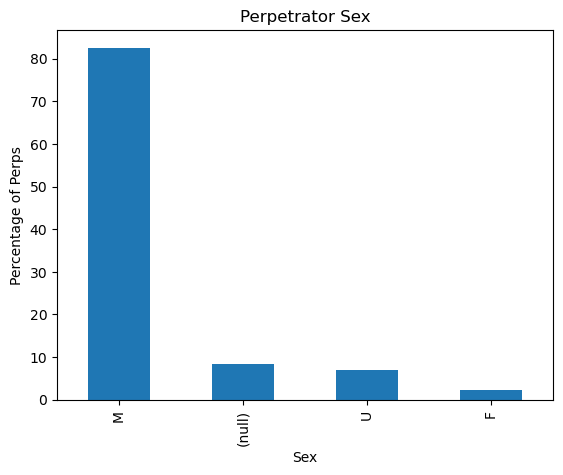

In [153]:
# Perpetrator Gender
perp_gender = df['perp_sex'].value_counts(normalize=True) * 100
print(perp_gender)

perp_gender.plot.bar()




plt.title('Perpetrator Sex')
plt.xlabel('Sex')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Perps')
plt.show()

vic_sex
M    90.165517
F     9.793103
U     0.041379
Name: proportion, dtype: float64


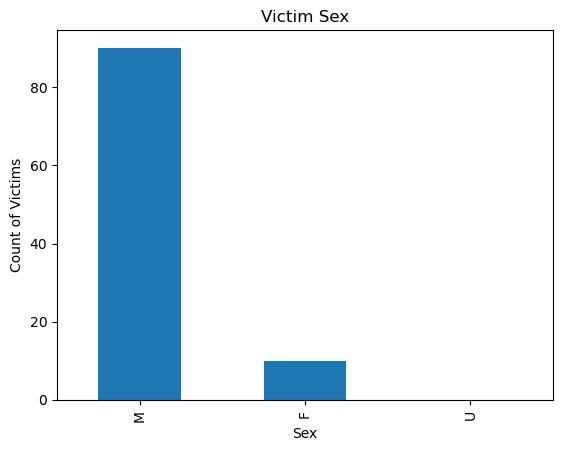

In [155]:
# Victim Gender
vic_sex = df['vic_sex'].value_counts(normalize=True) * 100
print(vic_sex)

vic_sex.plot.bar()


plt.title('Victim Sex')
plt.xlabel('Sex')
plt.xticks(rotation=90)
plt.ylabel('Count of Victims')
plt.show()

#Pereptrator Sex by Age Analysis

In [49]:
# Perpetrator sex and age information 

pivot_sex_by_age = df.pivot_table(values= 'Unnamed: 0', index = 'perp_age_group', columns='perp_sex', aggfunc='size')
print(pivot_sex_by_age)





perp_sex        (null)      F       M       U
perp_age_group                               
(null)          1628.0    NaN     NaN     NaN
1020               NaN    NaN     1.0     NaN
1028               NaN    NaN     1.0     NaN
18-24              NaN  165.0  6271.0    17.0
2021               NaN    NaN     1.0     NaN
224                NaN    NaN     1.0     NaN
25-44              NaN  203.0  5959.0     7.0
45-64              NaN   28.0   735.0     NaN
65+                NaN    2.0    64.0     NaN
940                NaN    NaN     1.0     NaN
<18                NaN   38.0  1709.0     3.0
UNKNOWN            NaN   17.0  1531.0  1321.0


perp_sex             M      F
perp_age_group               
18-24           6271.0  165.0
25-44           5959.0  203.0
45-64            735.0   28.0
65+               64.0    2.0
<18             1709.0   38.0


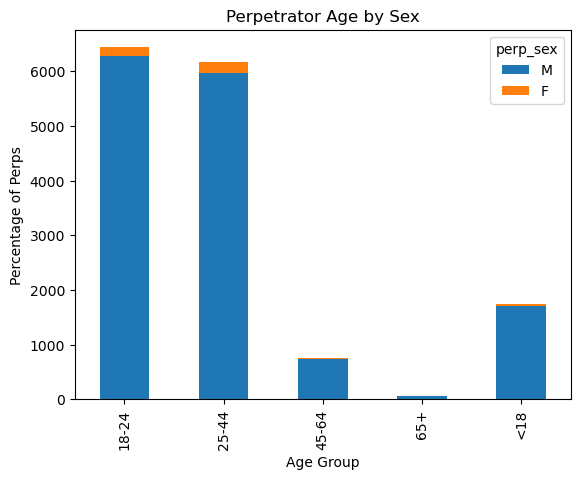

perp_sex                M         F
perp_age_group                     
18-24           97.436296  2.563704
25-44           96.705615  3.294385
45-64           96.330275  3.669725
65+             96.969697  3.030303
<18             97.824843  2.175157


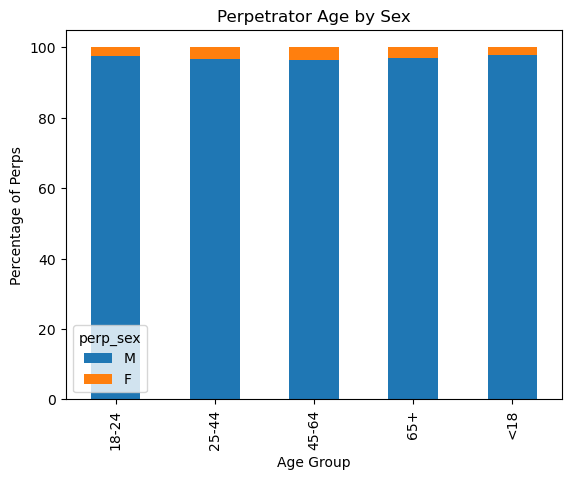

In [ ]:
#Filters out invalid age values
pivot_sex_by_age = df.pivot_table(index = 'perp_age_group', columns='perp_sex', aggfunc='size')


valid_ages = ['<18', '18-24', '25-44', '45-64', '65+']
valid_sex = ['M', 'F']

pivot_sex_by_age = pivot_sex_by_age[
    pivot_sex_by_age.index.isin(valid_ages)
].reindex(columns=valid_sex, fill_value=0)

print(pivot_sex_by_age)

# shows overall count by age group
pivot_sex_by_age.plot.bar(stacked=True)
plt.title('Perpetrator Age by Sex')
plt.xlabel('Age Group')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Perps')
plt.show()

pivot_sex_by_age = pivot_sex_by_age.div(
    pivot_sex_by_age.sum(axis=1),
    axis=0
) * 100

print(pivot_sex_by_age)

# shows percentage of make to female by age group
pivot_sex_by_age.plot.bar(stacked=True)
plt.title('Perpetrator Age by Sex')
plt.xlabel('Age Group')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Perps')
plt.show()


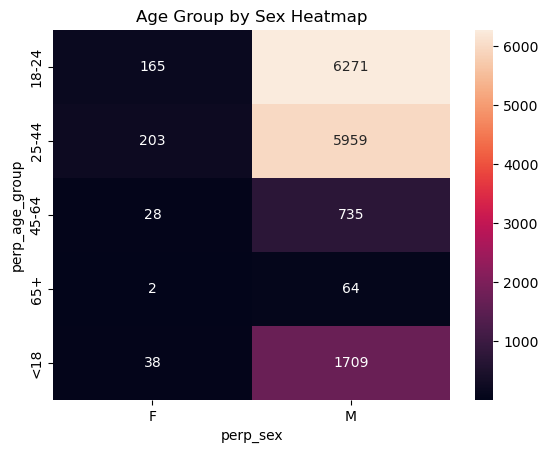

In [102]:
pivot_PERP = df.pivot_table(
    index='perp_age_group',
    columns='perp_sex',
    aggfunc='size',
    fill_value=0
)
pivot_PERP = pivot_PERP[pivot_PERP.index.isin(valid_ages)].reindex(columns=valid_sex, fill_value=0)

ax = sns.heatmap(pivot_PERP, annot=True, fmt='d')

ax.set_title("Age Group by Sex Heatmap")
plt.show()

#Victim and Perpetrator Sex by Location/Borough Analysis

vic_sex                      F     M  U
location_desc                          
ATM                          0     1  0
LOAN COMPANY                 0     1  0
STORAGE FACILITY             0     1  0
CHECK CASH                   0     1  0
DOCTOR/DENTIST               0     1  0
PHOTO/COPY STORE             0     2  0
BANK                         0     3  0
GYM/FITNESS FACILITY         1     3  0
FACTORY/WAREHOUSE            0     6  0
NONE                         0     8  0
VIDEO STORE                  0     8  0
CHAIN STORE                  0     8  0
DEPT STORE                   1     8  0
VARIETY STORE                0    10  0
CLOTHING BOUTIQUE            0    10  0
CANDY STORE                  1     9  0
SHOE STORE                   0    10  0
TELECOMM. STORE              2     9  0
JEWELRY STORE                0    11  0
DRUG STORE                   1    13  0
SUPERMARKET                  3    17  0
DRY CLEANER/LAUNDRY          3    25  0
STORE UNCLASSIFIED           2    31  0


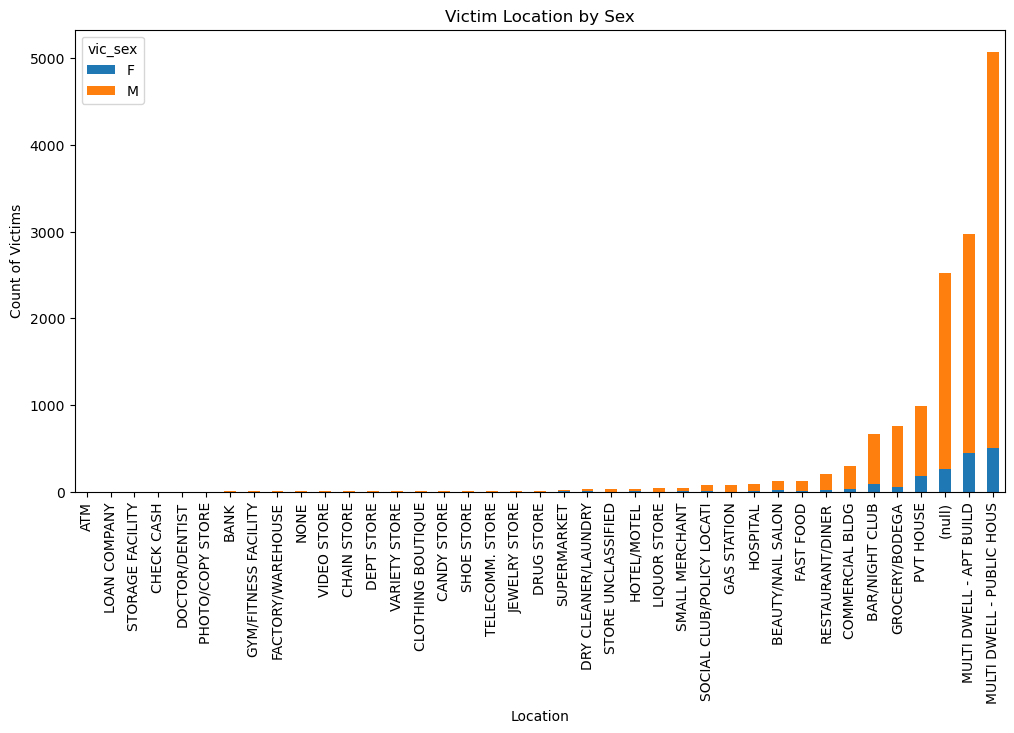

In [159]:
# Victim sex and location info
pivot_vic_sex_by_location = df.pivot_table(
    index='location_desc',
    columns='vic_sex',
    aggfunc='size',
    fill_value=0
)

# Sort by total counts descending
pivot_vic_sex_by_location = pivot_vic_sex_by_location.loc[
    pivot_vic_sex_by_location.sum(axis=1).sort_values(ascending=True).index
]
print(pivot_vic_sex_by_location)

valid_sex = ['F', 'M']
pivot_vic_sex_by_location = pivot_vic_sex_by_location.reindex(columns=valid_sex, fill_value=0)


pivot_vic_sex_by_location.plot.bar(
    stacked=True,
    figsize=(12,6)
    )
plt.title('Victim Location by Sex')
plt.xlabel('Location')
plt.xticks(rotation=90)
plt.ylabel('Count of Victims')
plt.show()

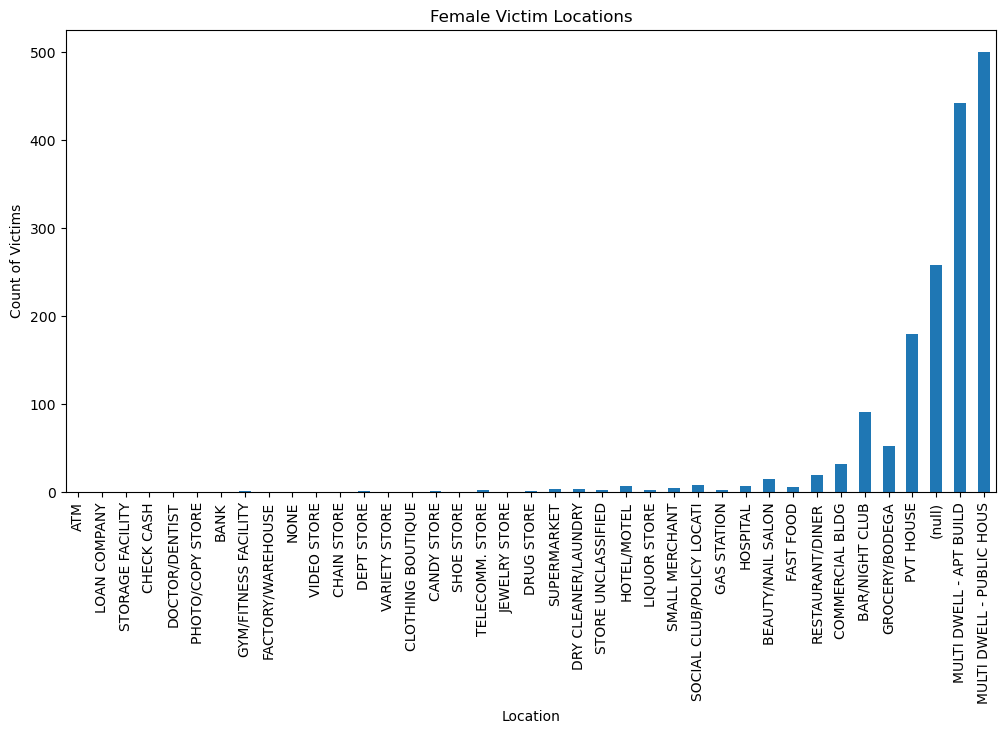

In [160]:
pivot_vic_sex_by_location = pivot_vic_sex_by_location['F']

pivot_vic_sex_by_location.plot.bar(
    figsize=(12,6)
    )
plt.title('Female Victim Locations')
plt.xlabel('Location')
plt.xticks(rotation=90)
plt.ylabel('Count of Victims')
plt.show()

perp_sex                      F       M
location_desc                          
(null)                     56.0  1474.0
BANK                        1.0     1.0
BAR/NIGHT CLUB              4.0   419.0
BEAUTY/NAIL SALON           1.0    79.0
CANDY STORE                 NaN     6.0
CHAIN STORE                 NaN     5.0
CHECK CASH                  NaN     1.0
CLOTHING BOUTIQUE           NaN     4.0
COMMERCIAL BLDG             3.0   161.0
DEPT STORE                  1.0     8.0
DOCTOR/DENTIST              NaN     1.0
DRUG STORE                  NaN    13.0
DRY CLEANER/LAUNDRY         NaN    15.0
FACTORY/WAREHOUSE           NaN     5.0
FAST FOOD                   1.0    80.0
GAS STATION                 1.0    45.0
GROCERY/BODEGA             11.0   503.0
GYM/FITNESS FACILITY        NaN     3.0
HOSPITAL                    NaN    25.0
HOTEL/MOTEL                 3.0    32.0
JEWELRY STORE               NaN    10.0
LIQUOR STORE                1.0    32.0
LOAN COMPANY                NaN     1.0


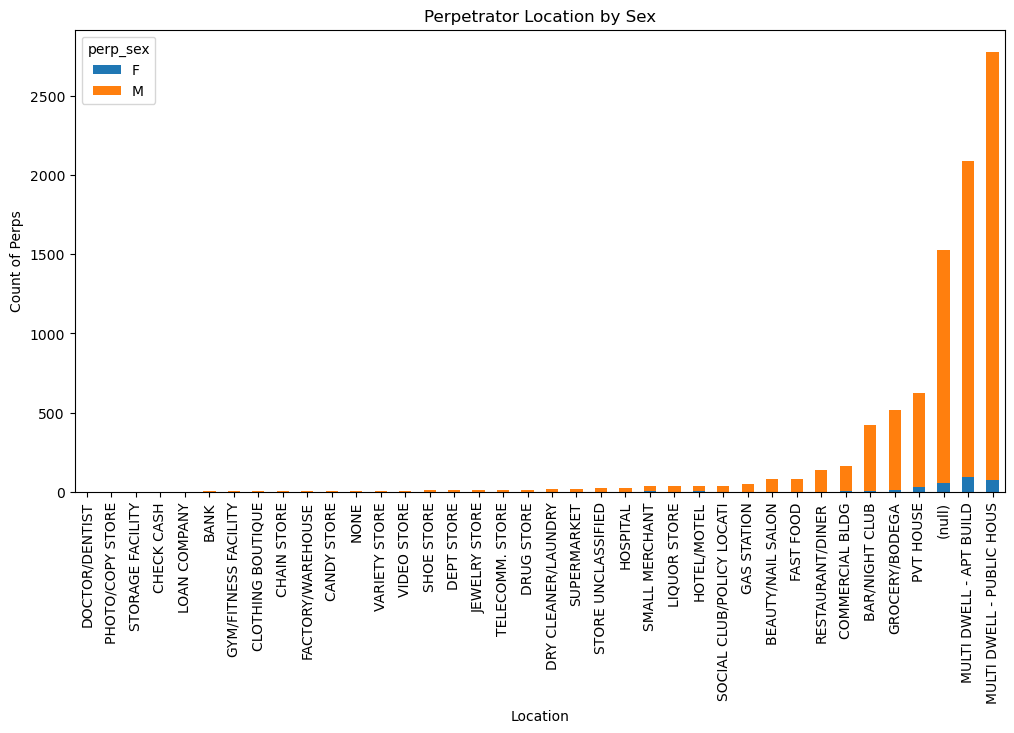

In [161]:
# Perpetrator sex and location info
pivot_perp_sex_by_location = df.pivot_table(values= 'Unnamed: 0', index = 'location_desc', columns='perp_sex', aggfunc='size').reindex(columns=valid_sex, fill_value=0)
print(pivot_perp_sex_by_location)

pivot_perp_sex_by_location = pivot_perp_sex_by_location.loc[
    pivot_perp_sex_by_location.sum(axis=1).sort_values(ascending=True).index
]


pivot_perp_sex_by_location.plot.bar(
    stacked=True,
    figsize=(12,6)
)

plt.title('Perpetrator Location by Sex')
plt.xlabel('Location')
plt.xticks(rotation=90)
plt.ylabel('Count of Perps')
plt.show()

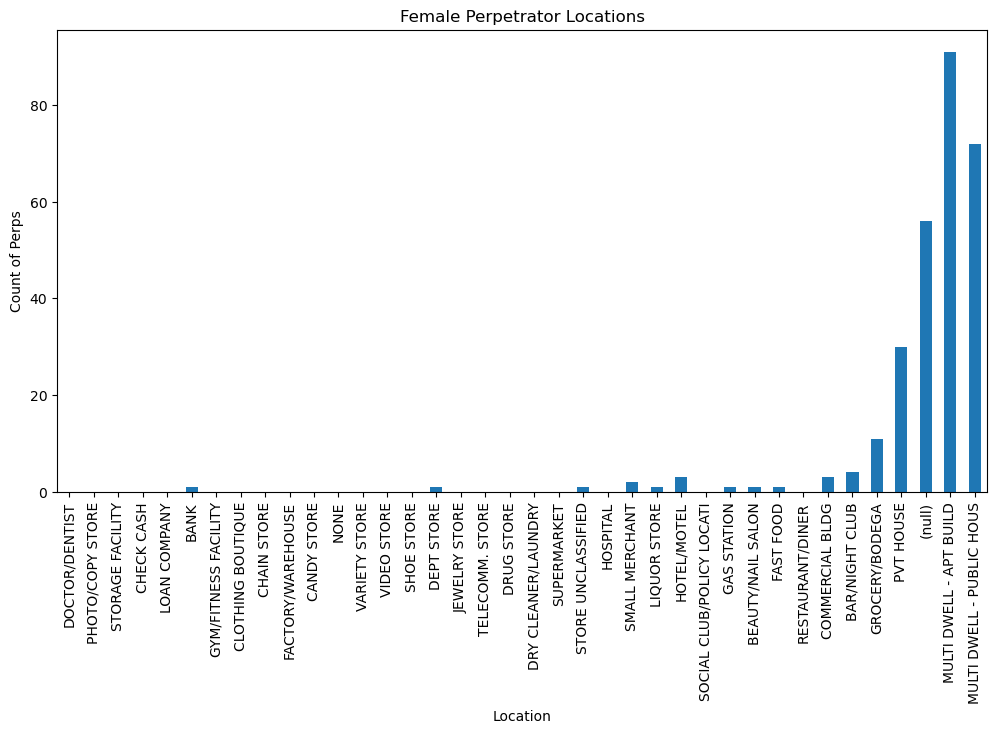

In [162]:
pivot_perp_sex_by_location = pivot_perp_sex_by_location['F']

pivot_perp_sex_by_location.plot.bar(
    stacked=True,
    figsize=(12,6)
)

plt.title('Female Perpetrator Locations')
plt.xlabel('Location')
plt.xticks(rotation=90)
plt.ylabel('Count of Perps')
plt.show()

vic_sex             F        M    U
boro                               
BRONX           777.0   7850.0  3.0
BROOKLYN       1120.0  10253.0  6.0
MANHATTAN       389.0   3481.0  3.0
QUEENS          457.0   3861.0  NaN
STATEN ISLAND    97.0    703.0  NaN


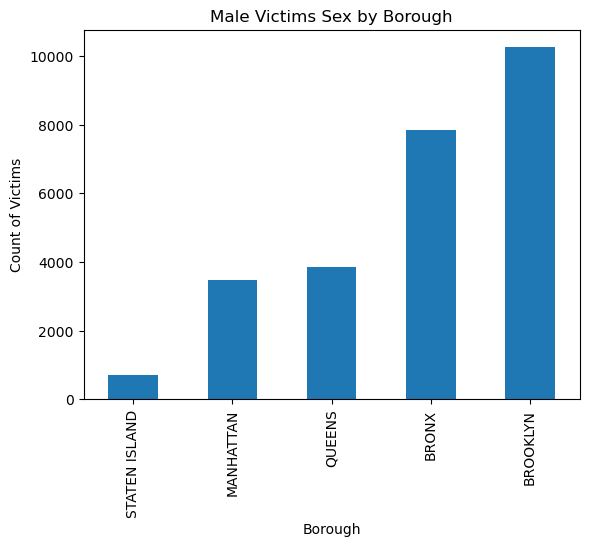

In [163]:
pivot_vic_sex_by_boro = df.pivot_table(values= 'Unnamed: 0', index = 'boro', columns='vic_sex', aggfunc='size')
print(pivot_vic_sex_by_boro)

pivot_vic_sex_by_boro = pivot_vic_sex_by_boro.reindex(columns=valid_sex, fill_value=0)

pivot_vic_sex_by_boro = pivot_vic_sex_by_boro.loc[
    pivot_vic_sex_by_boro.sum(axis=1).sort_values(ascending=True).index
]

pivot_vic_sex_by_boro = pivot_vic_sex_by_boro['M']

pivot_vic_sex_by_boro.plot.bar(stacked=True)

plt.title('Male Victims Sex by Borough')
plt.xlabel('Borough')
plt.xticks(rotation=90)
plt.ylabel('Count of Victims')
plt.show()

perp_sex       (null)    F     M    U
boro                                 
BRONX             518  131  5118  364
BROOKLYN          635  143  5738  584
MANHATTAN         191   87  2408  167
QUEENS            257   78  2417  210
STATEN ISLAND      27   14   593   24


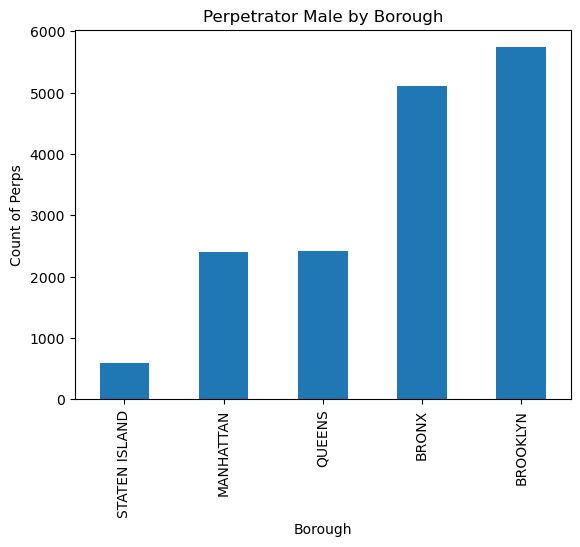

In [164]:
pivot_perp_sex_by_boro = df.pivot_table(values= 'Unnamed: 0', index = 'boro', columns='perp_sex', aggfunc='size')
print(pivot_perp_sex_by_boro)


pivot_perp_sex_by_boro = pivot_perp_sex_by_boro.reindex(columns=valid_sex, fill_value=0)

pivot_perp_sex_by_boro = pivot_perp_sex_by_boro.loc[
    pivot_perp_sex_by_boro.sum(axis=1).sort_values(ascending=True).index
]

pivot_perp_sex_by_boro = pivot_perp_sex_by_boro['M']
pivot_perp_sex_by_boro.plot.bar()

plt.title('Perpetrator Male by Borough')
plt.xlabel('Borough')
plt.xticks(rotation=90)
plt.ylabel('Count of Perps')
plt.show()

perp_sex       (null)    F     M    U
boro                                 
BRONX             518  131  5118  364
BROOKLYN          635  143  5738  584
MANHATTAN         191   87  2408  167
QUEENS            257   78  2417  210
STATEN ISLAND      27   14   593   24


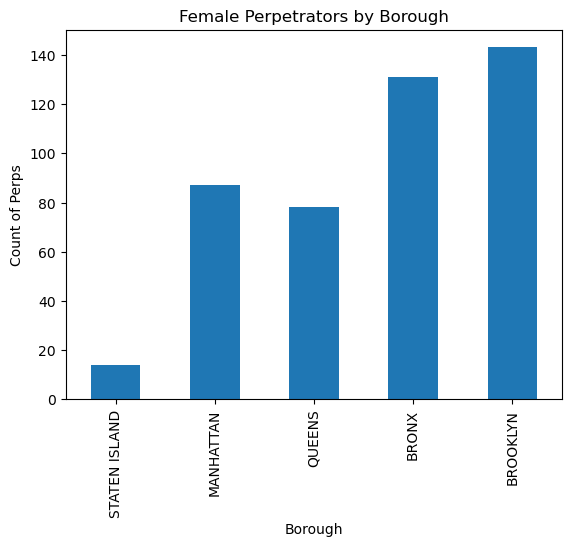

In [137]:
pivot_perp_sex_by_boro = df.pivot_table(values= 'Unnamed: 0', index = 'boro', columns='perp_sex', aggfunc='size')
print(pivot_perp_sex_by_boro)


pivot_perp_sex_by_boro = pivot_perp_sex_by_boro.reindex(columns=valid_sex, fill_value=0)

pivot_perp_sex_by_boro = pivot_perp_sex_by_boro.loc[
    pivot_perp_sex_by_boro.sum(axis=1).sort_values(ascending=True).index
]
pivot_perp_sex_by_boro = pivot_perp_sex_by_boro['F']

pivot_perp_sex_by_boro.plot.bar(stacked=True)

plt.title('Female Perpetrators by Borough')
plt.xlabel('Borough')
plt.xticks(rotation=90)
plt.ylabel('Count of Perps')
plt.show()

vic_sex             F        M    U
boro                               
BRONX           777.0   7850.0  3.0
BROOKLYN       1120.0  10253.0  6.0
MANHATTAN       389.0   3481.0  3.0
QUEENS          457.0   3861.0  NaN
STATEN ISLAND    97.0    703.0  NaN


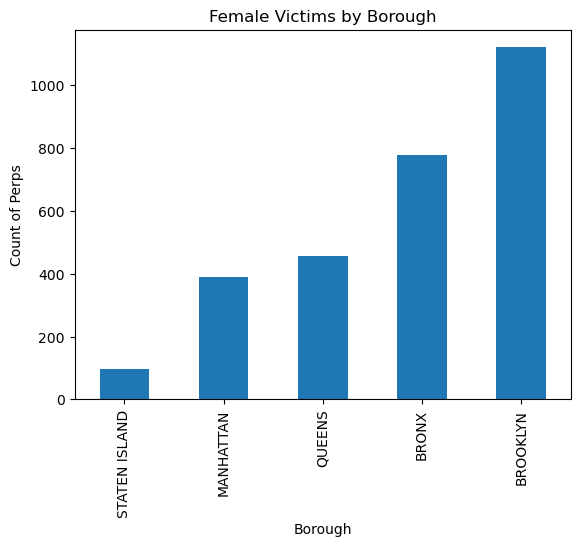

In [139]:
pivot_vic_sex_by_boro = df.pivot_table(values= 'Unnamed: 0', index = 'boro', columns='vic_sex', aggfunc='size')
print(pivot_vic_sex_by_boro)

pivot_vic_sex_by_boro = pivot_vic_sex_by_boro.reindex(columns=valid_sex, fill_value=0)

pivot_vic_sex_by_boro = pivot_vic_sex_by_boro.loc[
    pivot_vic_sex_by_boro.sum(axis=1).sort_values(ascending=True).index
]

pivot_vic_sex_by_boro = pivot_vic_sex_by_boro['F']

pivot_vic_sex_by_boro.plot.bar(stacked=True)

plt.title('Female Victims by Borough')
plt.xlabel('Borough')
plt.xticks(rotation=90)
plt.ylabel('Count of Perps')
plt.show()

#Victim and Perp Sex by Race

perp_sex                        (null)      F        M       U
perp_race                                                     
(null)                          1628.0    NaN      NaN     NaN
AMERICAN INDIAN/ALASKAN NATIVE     NaN    1.0      1.0     NaN
ASIAN / PACIFIC ISLANDER           NaN    5.0    175.0     NaN
BLACK                              NaN  294.0  11567.0    17.0
BLACK HISPANIC                     NaN   31.0   1441.0     2.0
UNKNOWN                            NaN    4.0    331.0  1330.0
WHITE                              NaN   19.0    275.0     NaN
WHITE HISPANIC                     NaN   99.0   2484.0     NaN


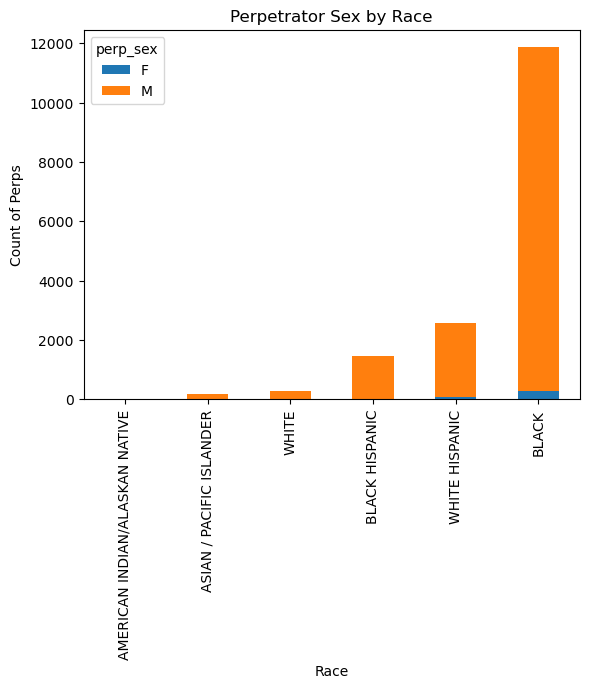

perp_sex                                F          M
perp_race                                           
AMERICAN INDIAN/ALASKAN NATIVE  50.000000  50.000000
ASIAN / PACIFIC ISLANDER         2.777778  97.222222
WHITE                            6.462585  93.537415
BLACK HISPANIC                   2.105978  97.894022
WHITE HISPANIC                   3.832753  96.167247
BLACK                            2.478712  97.521288


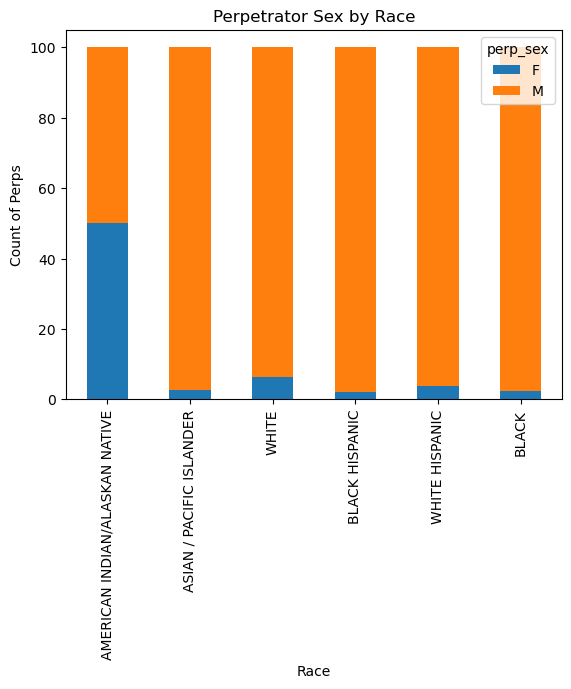

In [167]:
pivot_perp_sex_by_race = df.pivot_table(values= 'Unnamed: 0', index = 'perp_race', columns='perp_sex', aggfunc='size')
print(pivot_perp_sex_by_race )

valid_race = ['AMERICAN INDIAN/ALASKAN NATIVE', 'ASIAN / PACIFIC ISLANDER', 'BLACK', 'BLACK HISPANIC', 'WHITE', 'WHITE HISPANIC']
pivot_perp_sex_by_race = pivot_perp_sex_by_race[pivot_perp_sex_by_race.index.isin(valid_race)].reindex(columns=valid_sex, fill_value=0)

pivot_perp_sex_by_race = pivot_perp_sex_by_race.loc[
    pivot_perp_sex_by_race.sum(axis=1).sort_values(ascending=True).index
]

pivot_perp_sex_by_race.plot.bar(stacked = True)
#shows count
plt.title('Perpetrator Sex by Race')
plt.xlabel('Race')
plt.xticks(rotation=90)
plt.ylabel('Count of Perps')
plt.show()

pivot_perp_sex_by_race = pivot_perp_sex_by_race.div(
    pivot_perp_sex_by_race.sum(axis=1),
    axis=0
) * 100

print(pivot_perp_sex_by_race)

pivot_perp_sex_by_race.plot.bar(stacked = True)
# shows percentage
plt.title('Perpetrator Sex by Race')
plt.xlabel('Race')
plt.xticks(rotation=90)
plt.ylabel('Count of Perps')
plt.show()


vic_sex                            F      M  U
vic_race                                      
AMERICAN INDIAN/ALASKAN NATIVE     1     12  0
ASIAN / PACIFIC ISLANDER          47    417  0
BLACK                           1889  18593  4
BLACK HISPANIC                   268   2646  0
UNKNOWN                            1     62  8
WHITE                            124    594  0
WHITE HISPANIC                   510   3824  0


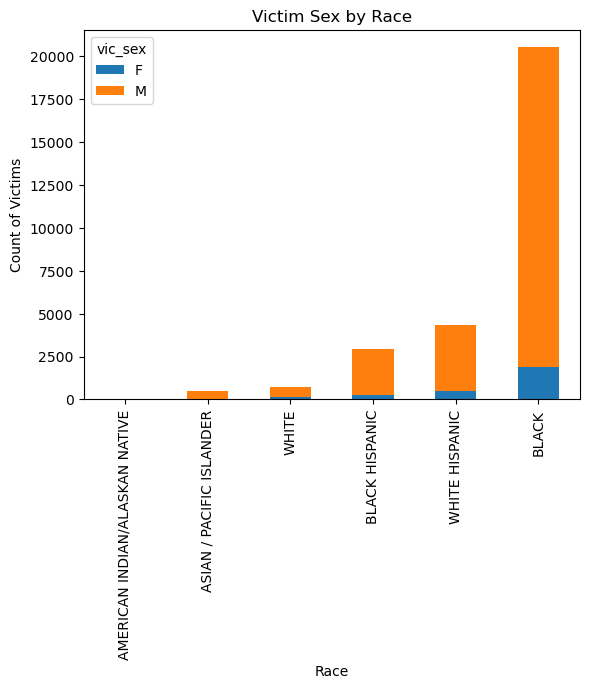

vic_sex                                 F          M
vic_race                                            
AMERICAN INDIAN/ALASKAN NATIVE   7.692308  92.307692
ASIAN / PACIFIC ISLANDER        10.129310  89.870690
WHITE                           17.270195  82.729805
BLACK HISPANIC                   9.196980  90.803020
WHITE HISPANIC                  11.767420  88.232580
BLACK                            9.222732  90.777268


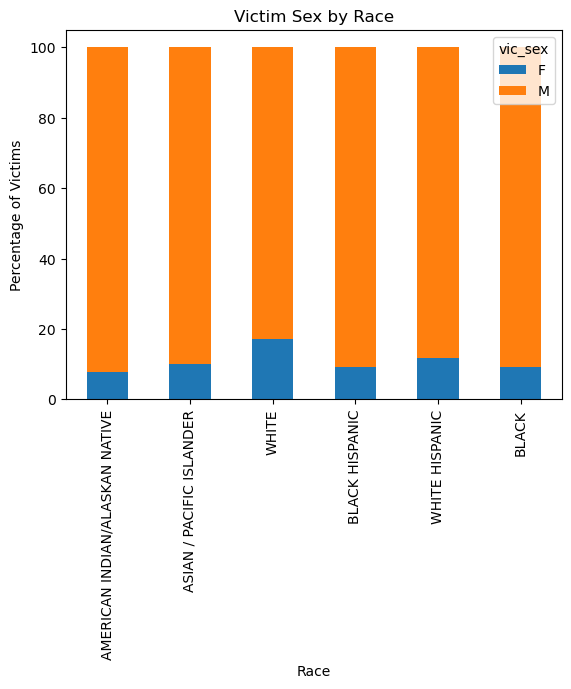

In [168]:
pivot_vic_sex_by_race = df.pivot_table(values= 'Unnamed: 0', index = 'vic_race', columns='vic_sex', aggfunc='size', fill_value=0)
print(pivot_vic_sex_by_race )

pivot_vic_sex_by_race = pivot_vic_sex_by_race[pivot_vic_sex_by_race.index.isin(valid_race)].reindex(columns=valid_sex, fill_value=0)

pivot_vic_sex_by_race = pivot_vic_sex_by_race.loc[
    pivot_vic_sex_by_race.sum(axis=1).sort_values(ascending=True).index]


# shows count 
pivot_vic_sex_by_race.plot.bar(stacked = True)

plt.title('Victim Sex by Race')
plt.xlabel('Race')
plt.xticks(rotation=90)
plt.ylabel('Count of Victims')
plt.show()

#shows percentage
pivot_vic_sex_by_race = pivot_vic_sex_by_race.div(
    pivot_vic_sex_by_race.sum(axis=1),
    axis=0
) * 100

print(pivot_vic_sex_by_race)
pivot_vic_sex_by_race.plot.bar(stacked = True)

plt.title('Victim Sex by Race')
plt.xlabel('Race')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Victims')
plt.show()